In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_rows",None)

In [2]:
# Creating df

cars_train = pd.read_csv(r"C:\Users\Dell\Downloads\cars_train.csv", header = None)
cars_test = pd.read_csv(r"C:\Users\Dell\Downloads\cars_test.csv", header = None)

In [3]:
cars_train

,0,1,2,3,4,5,6
0,vhigh,high,3,more,small,low,unacc
1,low,vhigh,3,4,small,med,unacc
2,low,high,5more,more,big,low,unacc
3,high,med,4,2,small,med,unacc
4,low,low,3,more,big,med,good
5,low,low,2,4,big,high,vgood
6,low,high,5more,more,big,high,vgood
7,high,med,5more,4,small,low,unacc
8,med,low,3,2,small,low,unacc
9,vhigh,low,3,4,big,low,unacc


In [4]:
cars_test

,0,1,2,3,4,5,6
0,med,vhigh,5more,4,small,low,unacc
1,vhigh,high,2,2,big,med,unacc
2,low,high,2,more,small,low,unacc
3,vhigh,vhigh,3,2,big,high,unacc
4,low,med,4,4,med,med,good
5,vhigh,low,3,more,med,low,unacc
6,high,low,5more,more,med,med,acc
7,vhigh,med,2,4,big,high,acc
8,high,vhigh,4,more,big,low,unacc
9,low,vhigh,3,4,small,high,acc


In [5]:
cars_train.columns = ['buying','maint','doors','persons','lug_boot','safety','classes']
cars_test.columns = ['buying','maint','doors','persons','lug_boot','safety','classes']

In [6]:
cars_train.shape

(1382, 7)

In [7]:
cars_test.shape

(346, 7)

In [8]:
cars_train.describe(include = 'all')

,buying,maint,doors,persons,lug_boot,safety,classes
count,1382,1382,1382,1382,1382,1382,1382
unique,4,4,4,3,3,3,4
top,high,vhigh,5more,more,big,high,unacc
freq,349,352,349,466,467,463,959


In [9]:
cars_test.describe(include = 'all')

,buying,maint,doors,persons,lug_boot,safety,classes
count,346,346,346,346,346,346,346
unique,4,4,4,3,3,3,4
top,low,low,2,2,med,low,unacc
freq,94,94,92,122,122,118,251


In [10]:
cars_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1382 entries, 0 to 1381
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1382 non-null   object
 1   maint     1382 non-null   object
 2   doors     1382 non-null   object
 3   persons   1382 non-null   object
 4   lug_boot  1382 non-null   object
 5   safety    1382 non-null   object
 6   classes   1382 non-null   object
dtypes: object(7)
memory usage: 75.7+ KB


In [11]:
cars_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 346 entries, 0 to 345
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    346 non-null    object
 1   maint     346 non-null    object
 2   doors     346 non-null    object
 3   persons   346 non-null    object
 4   lug_boot  346 non-null    object
 5   safety    346 non-null    object
 6   classes   346 non-null    object
dtypes: object(7)
memory usage: 19.1+ KB


In [12]:
cars_train.duplicated().sum()

0

In [13]:
cars_test.duplicated().sum()

0

In [14]:
cars_train.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
classes     0
dtype: int64

In [15]:
cars_test.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
classes     0
dtype: int64

In [16]:
cars_test.drop('classes', axis=1, inplace=True)

In [17]:
cars_test

,buying,maint,doors,persons,lug_boot,safety
0,med,vhigh,5more,4,small,low
1,vhigh,high,2,2,big,med
2,low,high,2,more,small,low
3,vhigh,vhigh,3,2,big,high
4,low,med,4,4,med,med
5,vhigh,low,3,more,med,low
6,high,low,5more,more,med,med
7,vhigh,med,2,4,big,high
8,high,vhigh,4,more,big,low
9,low,vhigh,3,4,small,high


In [18]:
from sklearn.preprocessing import LabelEncoder

#colname = ['buying','maint','doors','persons','lug_boot','safety','classes']
le = LabelEncoder()           

for x in cars_train.columns:
    cars_train[x] = le.fit_transform(cars_train[x])

cars_train

,buying,maint,doors,persons,lug_boot,safety,classes
0,3,0,1,2,2,1,2
1,1,3,1,1,2,2,2
2,1,0,3,2,0,1,2
3,0,2,2,0,2,2,2
4,1,1,1,2,0,2,1
5,1,1,0,1,0,0,3
6,1,0,3,2,0,0,3
7,0,2,3,1,2,1,2
8,2,1,1,0,2,1,2
9,3,1,1,1,0,1,2


In [19]:
le = LabelEncoder()           

for x in cars_test.columns:
    cars_test[x] = le.fit_transform(cars_test[x])



cars_test

,buying,maint,doors,persons,lug_boot,safety
0,2,3,3,1,2,1
1,3,0,0,0,0,2
2,1,0,0,2,2,1
3,3,3,1,0,0,0
4,1,2,2,1,1,2
5,3,1,1,2,1,1
6,0,1,3,2,1,2
7,3,2,0,1,0,0
8,0,3,2,2,0,1
9,1,3,1,1,2,0


In [20]:
X = cars_train.values[:,0:-1]
# selcts all rows(:)

Y = cars_train.values[:,-1]

Y= Y.astype(int)

In [21]:
X

array([[3, 0, 1, 2, 2, 1],
       [1, 3, 1, 1, 2, 2],
       [1, 0, 3, 2, 0, 1],
       ...,
       [0, 3, 3, 1, 1, 0],
       [2, 2, 2, 1, 0, 1],
       [2, 1, 3, 2, 2, 0]])

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X)

X = scaler.transform(X)

In [23]:
X

array([[ 1.33507272, -1.3488262 , -0.45682233,  1.21505861,  1.22565305,
         0.00176987],
       [-0.44760409,  1.32688358, -0.45682233, -0.01064285,  1.22565305,
         1.22474807],
       [-0.44760409, -1.3488262 ,  1.33418038,  1.21505861, -1.21505663,
         0.00176987],
       ...,
       [-1.33894249,  1.32688358,  1.33418038, -0.01064285,  0.00529821,
        -1.22120833],
       [ 0.44373431,  0.43498032,  0.43867903, -0.01064285, -1.21505663,
         0.00176987],
       [ 0.44373431, -0.45692294,  1.33418038,  1.21505861,  1.22565305,
        -1.22120833]])

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2,
                                                    random_state=0)

In [25]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(1105, 6)
(1105,)
(277, 6)
(277,)


In [26]:
from sklearn.tree import DecisionTreeClassifier

model_DecisionTree = DecisionTreeClassifier(criterion = 'gini', random_state=0)

model_DecisionTree.fit(X_train, Y_train)

Y_pred = model_DecisionTree.predict(X_test)

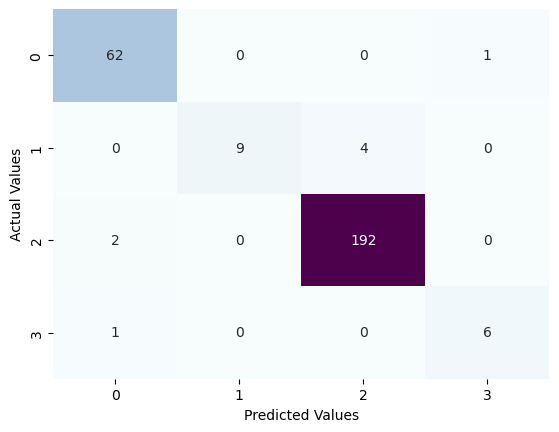

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97        63
           1       1.00      0.69      0.82        13
           2       0.98      0.99      0.98       194
           3       0.86      0.86      0.86         7

    accuracy                           0.97       277
   macro avg       0.95      0.88      0.91       277
weighted avg       0.97      0.97      0.97       277

Accuracy of the model:  0.9711191335740073


In [27]:
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report

cfm = confusion_matrix(Y_test, Y_pred)

sns.heatmap(
    cfm,
    annot = True,
    fmt = 'g',
    cbar = False,
    cmap = 'BuPu'
)

plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')

# Display the plot
plt.show()

# Print a detailed classification report
# Includes precision, recall, f1-score for each class
print("Classification report:")
print(classification_report(Y_test, Y_pred))

# Calculate overall accuracy of the model
acc = accuracy_score(Y_test, Y_pred)
print("Accuracy of the model: ", acc)

In [28]:
model_DecisionTree.score(X_train,Y_train)

1.0

In [29]:
print(list(zip(cars_train.columns[0:-1], model_DecisionTree.feature_importances_)))

[('buying', 0.156412079824748), ('maint', 0.2552160101709693), ('doors', 0.05357722637409044), ('persons', 0.1992414742127502), ('lug_boot', 0.09134739949517823), ('safety', 0.24420580992226387)]


In [30]:
from sklearn import tree

with open(r"model_DecisionTree.txt","w") as f:

#tree.export_graphviz()' exports the trained Decision tree structure
    # model_Decisiontree the trained decision tree model
    # feature_names=cars_train.column[0:-1] names of the input features (excludes target coolumn)
    # out_file=f saves the tree structure in DOT format into the opened file
    
    
    f = tree.export_graphviz(model_DecisionTree,
                            feature_names=cars_train.columns[0:-1],
                            out_file=f)

# Hyperparameter Tuning

In [31]:
from sklearn.tree import DecisionTreeClassifier

model_DecisionTree = DecisionTreeClassifier(
criterion='gini',
random_state=0,
splitter='best',
min_samples_leaf=5,
max_depth=10,
max_leaf_nodes=15)

model_DecisionTree.fit(X_train, Y_train)

Y_pred = model_DecisionTree.predict(X_test)

list(zip(Y_test, Y_pred))
print(list(zip(Y_test, Y_pred)))

[(2, 2), (2, 2), (0, 0), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (0, 0), (2, 2), (0, 0), (2, 2), (2, 2), (1, 0), (1, 0), (0, 0), (2, 2), (2, 2), (2, 0), (2, 2), (2, 2), (0, 0), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 0), (0, 0), (2, 2), (2, 2), (2, 2), (1, 3), (0, 0), (2, 2), (0, 3), (2, 2), (0, 0), (2, 2), (0, 0), (2, 2), (0, 0), (2, 2), (0, 0), (2, 2), (2, 2), (3, 3), (2, 2), (0, 0), (2, 2), (2, 2), (1, 0), (0, 0), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (0, 0), (2, 2), (2, 2), (2, 2), (1, 0), (2, 0), (0, 0), (2, 2), (2, 2), (0, 0), (3, 3), (2, 2), (2, 2), (3, 3), (2, 2), (0, 0), (0, 0), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (2, 2), (2, 2), (0, 0), (0, 0), (1, 0), (2, 0), (0, 0), (2, 2), (2, 2), (2, 2), (0, 0), (2, 2), (2, 2), (2, 2), (1, 0), (2, 2), (0, 0), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (0, 0), (0, 3), (2, 2), (2, 0), (2, 2), (0, 2), (0, 0), (2, 2), (0, 0), (2, 2), (2, 2),

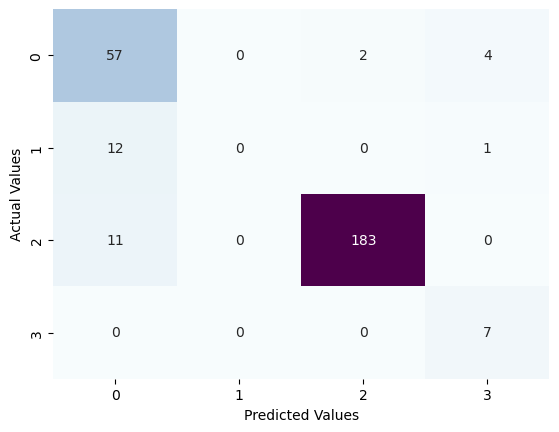

Classification report:
              precision    recall  f1-score   support

           0       0.71      0.90      0.80        63
           1       0.00      0.00      0.00        13
           2       0.99      0.94      0.97       194
           3       0.58      1.00      0.74         7

    accuracy                           0.89       277
   macro avg       0.57      0.71      0.62       277
weighted avg       0.87      0.89      0.88       277

Accuracy of the model:  0.8916967509025271


In [32]:
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report

cfm = confusion_matrix(Y_test, Y_pred)

sns.heatmap(
    cfm,
    annot = True,
    fmt = 'g',
    cbar = False,
    cmap = 'BuPu'
)

plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')

# Display the plot
plt.show()

# Print a detailed classification report
# Includes precision, recall, f1-score for each class
print("Classification report:")
print(classification_report(Y_test, Y_pred))

# Calculate overall accuracy of the model
acc = accuracy_score(Y_test, Y_pred)
print("Accuracy of the model: ", acc)

In [33]:
from sklearn import tree

with open(r"model_DecisionTree11.txt","w") as f:

#tree.export_graphviz()' exports the trained Decision tree structure
    # model_Decisiontree the trained decision tree model
    # feature_names=cars_train.column[0:-1] names of the input features (excludes target coolumn)
    # out_file=f saves the tree structure in DOT format into the opened file
    
    
    f = tree.export_graphviz(model_DecisionTree,
                            feature_names=cars_train.columns[0:-1],
                            out_file=f)

In [34]:
import os
os.getcwd()

'C:\\Users\\Dell\\Machine Learning'

In [35]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression()

classifier.fit(X_train, Y_train)

Y_pred = classifier.predict(X_test)

print(Y_pred)

print(list(zip(Y_test, Y_pred)))

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 2 2 2 2 2 2 0 2 2 2 2 2
 2 2 2 3 2 2 2 2 2 0 2 2 2 2 2 2 2 0 2 0 0 2 0 0 2 0 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 0 2 2 2 2 0 2 0 2 2 2 2 2 2 2 2 0 2 0 2 2 2
 2 2 2 2 0 2 2 2 2 2 2 2 0 2 3 0 2 2 2 2 2 2 2 3 2 0 2 2 2 0 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 0 2 2 2 0 2 2 2 0 2 2 2 2 2 2 2 0 0 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 2 0 2 0 2 2 2 2 0 2 0 2 2 2 2 2 2 0 2 2 2 2
 2 0 0 2 2 2 2 2 2 0 2 0 0 2 2 2 2 2]
[(2, 2), (2, 2), (0, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (0, 2), (2, 2), (0, 2), (2, 2), (2, 2), (1, 2), (1, 2), (0, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (0, 3), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 0), (2, 2), (0, 2), (2, 2), (2, 2), (2, 2), (1, 2), (0, 2), (2, 2), (0, 3), (2, 2), (0, 2), (2, 2), (0, 2), (2, 2), (0, 0), (2, 2), (0, 2), (2, 2), (2, 2), (3, 2), (2, 2), (0, 2), (2, 

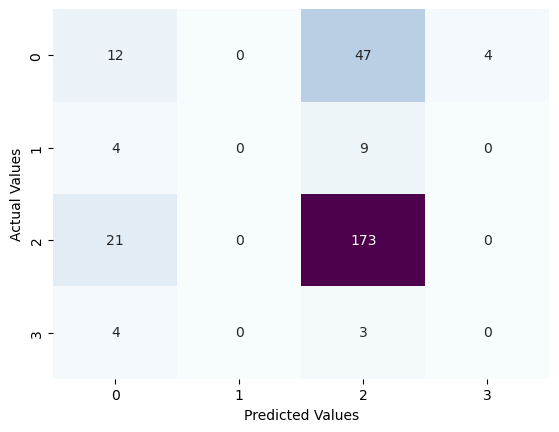

Classification report:
              precision    recall  f1-score   support

           0       0.29      0.19      0.23        63
           1       0.00      0.00      0.00        13
           2       0.75      0.89      0.81       194
           3       0.00      0.00      0.00         7

    accuracy                           0.67       277
   macro avg       0.26      0.27      0.26       277
weighted avg       0.59      0.67      0.62       277

Accuracy of the model:  0.6678700361010831


In [36]:
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report

cfm = confusion_matrix(Y_test, Y_pred)

sns.heatmap(
    cfm,
    annot = True,
    fmt = 'g',
    cbar = False,
    cmap = 'BuPu'
)

plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')

# Display the plot
plt.show()

# Print a detailed classification report
# Includes precision, recall, f1-score for each class
print("Classification report:")
print(classification_report(Y_test, Y_pred))

# Calculate overall accuracy of the model
acc = accuracy_score(Y_test, Y_pred)
print("Accuracy of the model: ", acc)

# Testing

In [37]:
cars_test.head()

,buying,maint,doors,persons,lug_boot,safety
0,2,3,3,1,2,1
1,3,0,0,0,0,2
2,1,0,0,2,2,1
3,3,3,1,0,0,0
4,1,2,2,1,1,2


In [38]:
test = cars_test.values

test = scaler.transform(test)

In [39]:
from sklearn.tree import DecisionTreeClassifier

model_DecisionTree = DecisionTreeClassifier(criterion = 'gini', random_state=0)

model_DecisionTree.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=0)

In [40]:
test_pred = model_DecisionTree.predict(test)

test_pred

array([2, 2, 2, 2, 1, 2, 0, 0, 2, 0, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 3,
       2, 0, 2, 2, 2, 2, 2, 0, 1, 3, 1, 2, 0, 2, 0, 2, 2, 2, 2, 3, 2, 2,
       0, 0, 2, 2, 1, 2, 2, 2, 1, 2, 0, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0,
       2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 0, 2, 2, 3, 2, 2, 0, 2, 0, 3, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2,
       2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2,
       2, 2, 0, 0, 2, 2, 2, 2, 3, 2, 0, 2, 2, 0, 2, 2, 2, 2, 0, 3, 0, 0,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 3, 0, 2, 2, 2, 3, 2, 2, 1, 2,
       2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 3, 2, 2, 0,
       2, 0, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 0, 2,
       2, 2, 0, 2, 2, 0, 2, 2, 2, 1, 1, 2, 2, 2, 0, 2, 2, 0, 3, 3, 0, 0,
       0, 2, 2, 2, 3, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2,

In [41]:
cars_test = pd.read_csv(r"C:\Users\Dell\Downloads\cars_test.csv", header = None)

cars_test.columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'classes']

cars_test['Pred'] = test_pred

cars_test['Pred'] = cars_test['Pred'].map({0: "acc", 1: "good", 2: "unacc", 3: "vgood"})

cars_test

,buying,maint,doors,persons,lug_boot,safety,classes,Pred
0,med,vhigh,5more,4,small,low,unacc,unacc
1,vhigh,high,2,2,big,med,unacc,unacc
2,low,high,2,more,small,low,unacc,unacc
3,vhigh,vhigh,3,2,big,high,unacc,unacc
4,low,med,4,4,med,med,good,good
5,vhigh,low,3,more,med,low,unacc,unacc
6,high,low,5more,more,med,med,acc,acc
7,vhigh,med,2,4,big,high,acc,acc
8,high,vhigh,4,more,big,low,unacc,unacc
9,low,vhigh,3,4,small,high,acc,acc


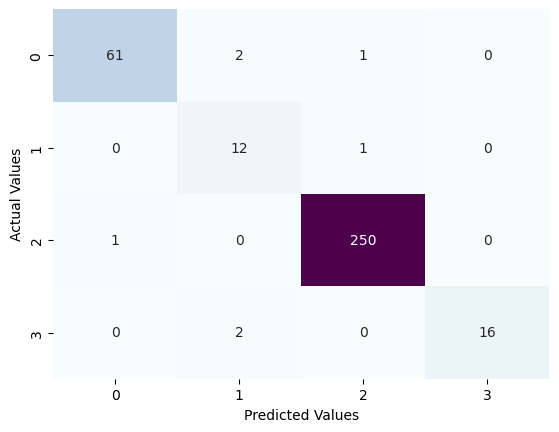

Classification report:
              precision    recall  f1-score   support

         acc       0.98      0.95      0.97        64
        good       0.75      0.92      0.83        13
       unacc       0.99      1.00      0.99       251
       vgood       1.00      0.89      0.94        18

    accuracy                           0.98       346
   macro avg       0.93      0.94      0.93       346
weighted avg       0.98      0.98      0.98       346

Accuracy of the model:  0.9797687861271677


In [42]:
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report

cfm = confusion_matrix(cars_test.classes, cars_test.Pred)

sns.heatmap(
    cfm,
    annot = True,
    fmt = 'g',
    cbar = False,
    cmap = 'BuPu'
)

plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')

# Display the plot
plt.show()

# Print a detailed classification report
# Includes precision, recall, f1-score for each class
print("Classification report:")
print(classification_report(cars_test.classes, cars_test.Pred))

# Calculate overall accuracy of the model
acc = accuracy_score(cars_test.classes, cars_test.Pred)
print("Accuracy of the model: ", acc)

In [43]:
log_test = classifier.predict(test)

log_test

array([2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2,
       3, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2,
       2, 2, 0, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2,
       2, 0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 0,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0,
       2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 0, 2, 2, 3, 2,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2,
       2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 3, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 0, 2, 2, 2, 2,
       0, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 0, 0, 2, 0, 2, 3, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2,

In [44]:
cars_test['Log_Pred'] = log_test

cars_test['Log_Pred'] = cars_test['Log_Pred'].map({0: 'acc', 1: 'good', 2: 'unacc', 3: 'vgood'})

cars_test

,buying,maint,doors,persons,lug_boot,safety,classes,Pred,Log_Pred
0,med,vhigh,5more,4,small,low,unacc,unacc,unacc
1,vhigh,high,2,2,big,med,unacc,unacc,unacc
2,low,high,2,more,small,low,unacc,unacc,unacc
3,vhigh,vhigh,3,2,big,high,unacc,unacc,unacc
4,low,med,4,4,med,med,good,good,unacc
5,vhigh,low,3,more,med,low,unacc,unacc,unacc
6,high,low,5more,more,med,med,acc,acc,acc
7,vhigh,med,2,4,big,high,acc,acc,unacc
8,high,vhigh,4,more,big,low,unacc,unacc,acc
9,low,vhigh,3,4,small,high,acc,acc,unacc


# Random Forest

In [47]:
from sklearn.ensemble import RandomForestClassifier

model_RandomForest = RandomForestClassifier(n_estimators=100, random_state=0)

model_RandomForest.fit(X_train, Y_train)

Y_pred = model_RandomForest.predict(X_test)

print(Y_pred)

# print(list(zip(Y_test, Y_pred)))

[2 2 0 2 2 2 2 2 2 2 2 0 2 0 2 2 1 1 0 2 2 0 2 2 0 2 2 2 2 2 2 2 2 0 2 2 2
 1 0 2 0 2 0 2 0 2 0 2 0 2 2 3 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 1 2 0 2 2 0 3
 2 2 3 2 0 0 2 2 2 2 2 2 0 0 0 0 0 2 2 0 0 1 2 0 2 2 2 0 2 2 2 1 2 0 2 2 2
 2 2 2 0 0 2 0 2 0 0 2 0 2 2 0 1 0 0 0 0 2 2 2 0 1 0 2 2 2 0 2 0 2 2 2 2 2
 2 2 2 2 0 2 2 2 0 0 0 2 2 2 0 2 2 2 3 0 2 2 3 2 2 2 2 2 2 2 2 2 2 2 2 0 2
 2 2 2 3 2 0 2 2 2 2 0 2 2 2 0 2 2 0 0 2 2 2 2 0 2 2 2 2 0 2 2 0 2 2 2 2 2
 2 2 2 2 2 2 2 1 2 2 2 2 0 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 2
 0 0 2 1 0 2 2 2 2 2 2 2 2 2 2 2 0 2]


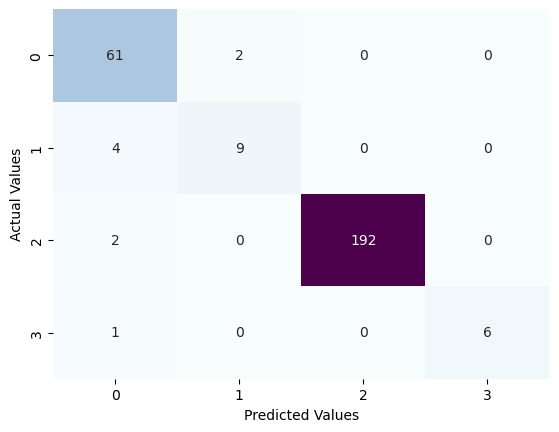

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93        63
           1       0.82      0.69      0.75        13
           2       1.00      0.99      0.99       194
           3       1.00      0.86      0.92         7

    accuracy                           0.97       277
   macro avg       0.93      0.88      0.90       277
weighted avg       0.97      0.97      0.97       277

Accuracy of the model:  0.9675090252707581


In [48]:
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report

cfm = confusion_matrix(Y_test, Y_pred)

sns.heatmap(
    cfm,
    annot = True,
    fmt = 'g',
    cbar = False,
    cmap = 'BuPu'
)

plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')

# Display the plot
plt.show()

# Print a detailed classification report
# Includes precision, recall, f1-score for each class
print("Classification report:")
print(classification_report(Y_test, Y_pred))

# Calculate overall accuracy of the model
acc = accuracy_score(Y_test, Y_pred)
print("Accuracy of the model: ", acc)